In [9]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter, lidar_processor
# import subroutines
# import vis_eulag

plt.style.use('latex_default.mplstyle')

"""Config"""
VERTICAL_CUTOFF = 15 # km (LAMBDA_CUT)
TEMPORAL_CUTOFF = 8*60 # min (TAU_CUT)

In [12]:
"""EULAG simulations"""
folder = "/work/bd0620/b309199/patagonia"
# folder = "/scratch/b/b309199"

# simulations = ["pata_2D_pha0", "pata_2D_fitzroy", "pata_2D_darwin"]
simulations = ["pata_1D_pha0", "pata_1D_pha1", "pata_1D_tide"]

eulag_sets = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath)
    eulag_sets.append(ds_lidars)

In [13]:
"""CORAL measurements"""
folder_obs = "/home/b/b309199/data/coral-2018-06"
obs_list = ["20180616-2101_T15Z900.nc", "20180617-2101_T15Z900.nc", "20180618-1544_T15Z900.nc"]
config = configparser.ConfigParser()
config.read("/home/b/b309199/data/coral-2018-06/coral.ini")
coral_sets = []
for obs in obs_list:
    fpath = os.path.join(folder_obs, obs)
    ds = lidar_processor.open_and_decode_lidar_measurement(fpath)
    
    # ds = lidar_processor.process_lidar_measurement(config, ds)
    ds['alt_plot'] = (ds.altitude + ds.altitude_offset.values + ds.station_height.values) / 1000 #km
    ds.attrs['vres'] = (ds['alt_plot'][1]-ds['alt_plot'][0]).values # in km
    ds.attrs['tres'] = (ds['time'][1]-ds['time'][0]).values.astype("timedelta64[m]").astype('int') # in minutes
    
    ds = lidar_processor.calculate_primes(ds, TEMPORAL_CUTOFF, VERTICAL_CUTOFF)
    coral_sets.append(ds)

In [14]:
coral_sets[0]

<xarray.Dataset> Size: 11MB
Dimensions:                 (value: 1, channels: 1, time: 143, altitude: 1600,
                             t: 143, z: 1600)
Coordinates:
  * altitude                (altitude) uint32 6kB 68 168 268 ... 159868 159968
  * time                    (time) datetime64[ns] 1kB 2018-06-16T21:21:13 ......
Dimensions without coordinates: value, channels, t, z
Data variables: (12/27)
    station_latitude        (value) float64 8B ...
    station_longitude       (value) float64 8B ...
    station_height          (value) uint32 4B ...
    time_offset             (value) datetime64[ns] 8B ...
    altitude_offset         (value) uint32 4B ...
    wavelength              (channels) float64 8B ...
    ...                      ...
    tprime_vbwf             (t, z) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tbg_vbwf                (t, z) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    temperature_interp      (time, altitude) float32 915kB 0.0 0.0 ... 0.0 0.0
    tprime_tbwf             (t, z) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tbg_tbwf                (t, z) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tprime_nm               (time, altitude) float32 915kB 0.0 0.0 ... 0.0 0.0
Attributes: (12/27)
    title:             Lidar temperature profiles
    summary:           This file contains temperature profiles retrieved from...
    comment:           Vibrational Raman channel is used for altitudes below ...
    institution:       German Aerospace Center (DLR), Institute of Atmospheri...
    creator_name:      Bernd Kaifler
    creator_url:       http://www.dlr.de/pa
    ...                ...
    reference_date:    1970-01-01 00:00:00.00
    start_time_utc:    2018-06-16 21:21:13
    end_time_utc:      2018-06-17 09:11:13
    duration_str:      11h45min
    vres:              0.1
    tres:              5

In [ ]:
"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [7,7,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(3,3, sharex=True, sharey=True, figsize=(12,9), gridspec_kw=gskw)

for ax in axes[-1,0:3]:
    ax.set_axis_off()

axes[0,0], contf = plt_virtual_lidar(axes[0,0], lidar_sets[0][0], simlabel=simulations[0])
axes[0,1], _ = plt_virtual_lidar(axes[0,1], lidar_sets[1][0], simlabel=simulations[1])
axes[0,2], _ = plt_virtual_lidar(axes[0,2], lidar_sets[2][0], simlabel=simulations[2])
axes[1,0], _ = plt_virtual_lidar(axes[1,0], lidar_sets[0][1])
axes[1,1], _ = plt_virtual_lidar(axes[1,1], lidar_sets[1][1])
axes[1,2], _ = plt_virtual_lidar(axes[1,2], lidar_sets[2][1])

xpp = 0.96
ypp = 0.93
axes[0,0].text(1-xpp, ypp, f"Fitzroy", transform=axes[0,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
axes[1,0].text(1-xpp, ypp, f"CORAL", transform=axes[1,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# axes[0,0].text(1-xpp, ypp, f"Fitzroy (x: {ds_lid.xpos}km, y: {ds_lid.ypos}km)", transform=axes[0,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# axes[1,0].text(1-xpp, ypp, f"CORAL (x: {ds_lid.xpos}km, y: {ds_lid.ypos}km)", transform=axes[1,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})


# cbar = fig.colorbar(contf_ep, ax=axes[-1,1], orientation='horizontal', shrink=0.8, fraction=1, aspect=17)
# # cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$ $\cdot 10^{-3}$")
# cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$")
# cbar = fig.colorbar(contf_mf, ax=axes[-1,2], orientation='horizontal', ticks=clev_l_mf, shrink=0.8, fraction=1, aspect=17)
# cbar.set_label(cbar_mf_label)


axes[0,0].tick_params(labelbottom=False,labeltop=True, labelleft=True)
axes[0,0].xaxis.set_label_position('top')
# axes[0,0].yaxis.set_label_position('right')
axes[0,0].set_xlabel('time / h')
axes[0,0].set_ylabel('altitude z / km')

axes[1,0].tick_params(labelbottom=False,labeltop=False, labelleft=True)
axes[1,0].set_ylabel('altitude z / km')

axes[0,1].tick_params(labelbottom=False,labeltop=True, labelleft=False)
axes[0,1].xaxis.set_label_position('top')
axes[0,1].set_xlabel('time / h')

axes[0,2].tick_params(labelbottom=False,labeltop=True, labelleft=False)
axes[0,2].xaxis.set_label_position('top')
axes[0,2].set_xlabel('time / h')

cbar = fig.colorbar(contf, ax=axes[-1,:], orientation='horizontal', ticks=clev_l, shrink=0.6, fraction=1,aspect=40) # anchor=(0,0)
cbar.set_label(r"T' / K")

fig_title = "lidar_comp_temp.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')

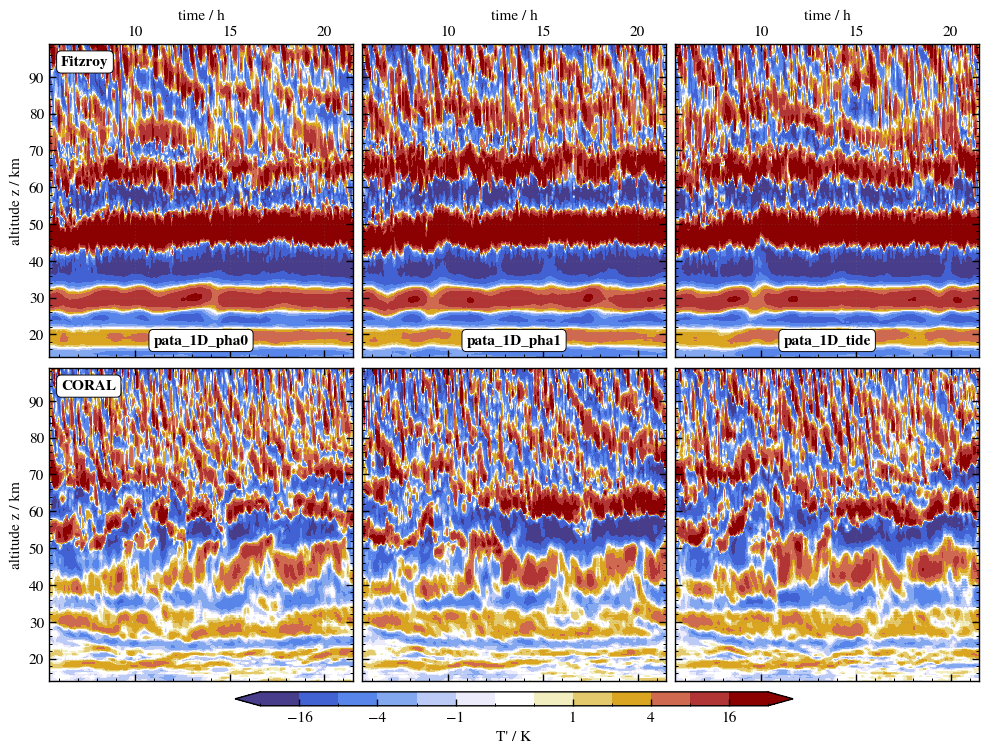

In [8]:
def plt_virtual_lidar(axlid, ds_lid, simlabel=None):
    ## tref_lid = np.where(ds_lid.time.values[:,0] == tstamp_ref)[0]
    if var == "mf":
        uw   = ds_lid['w'].values * (ds_lid['u'].values-ds_lid['ue'].values)
        mfx  = ds_lid['rh0'].values * uw
        mfx = plt_helper.gaussian_filter_fft(mfx, 1, lambdaz, 1, ds.dz00)
        cvar = mfx*1000
    elif var == "ep":
        tloc, tenv = plt_helper.get_eulag_t_and_tenv(ds_lid['th'].values, ds_lid['the'].values, ds_lid['p'].values, ds_lid['ppe'].values, ds.cap, ds.pref00)
        epm = 1/2*(ds.g/ds.bv)**2 * ((tloc-tenv)/tenv)**2
        epm = plt_helper.gaussian_filter_fft(epm, 1, lambdaz, 1, ds.dz00)
        epm = np.where(epm>clev[0],epm,np.nan)
        cvar = epm
    elif var == "u":
        cvar = ds_lid["u"] - ds_lid["ue"]
    elif var == "w":
        cvar = ds_lid["w"]
    elif var == "t":
        tloc, tenv = plt_helper.get_eulag_t_and_tenv(ds_lid['th'].values, ds_lid['the'].values, ds_lid['p'].values, ds_lid['ppe'].values, ds.cap, ds.pref00)
        vert_res = (ds_lid.zcr[-1,-1] - ds_lid.zcr[-1,-2]).values
        time_res = (ds_lid.time[-1,-1] - ds_lid.time[-2,-1]).values * 60 # min
        tprime_bwf15, tbg15 = filter.butterworth_filter(tloc, cutoff=1/VERTICAL_CUTOFF, fs=1/vert_res, order=5, mode='both')
        
        tprime_bwf_time, tbg_time = filter.butterworth_filter(tprime_bwf15.T, cutoff=1/(0.25*60), fs=1/time_res, order=5, mode='both')
        cvar = tbg_time.T

        tprime_bwf_time, tbg_time = filter.butterworth_filter(tbg_time, cutoff=1/TEMPORAL_CUTOFF, fs=1/time_res, order=5, mode='both')
        cvar = tprime_bwf_time.T

        tprime = tloc - tenv
        tmean = np.mean(tprime[100:], axis=0)
        cvar = tprime - tmean
        cvar = tprime
    else:
        cvar = ds_lid[var]
    contf = axlid.contourf(ds_lid.time, ds_lid.zcr, cvar, levels=clev,
                        cmap=cmap, norm=norm, extend='both')

    # isentropes = axlid.contour(ds_lid.time, ds_lid.zcr, ds_lid.the + ds_lid.th, levels=thlev, colors='k', lw=lw2)
    # ax.clabel(isentropes, thlev[1::], fontsize=8, fmt='%1.0f K', inline_spacing=1, inline=True, 
    #             manual=[(8,ds.zcr[t,10,0,x]), (8,ds.zcr[t,-15,0,x])]) # ha='left', thlev[1::3]

    axlid.plot(ds_lid.time, surf_factor*ds_lid.zcr[:,0], lw=2, color='black')
    
    axlid.yaxis.set_major_locator(MultipleLocator(10))
    axlid.xaxis.set_minor_locator(AutoMinorLocator())
    axlid.yaxis.set_minor_locator(AutoMinorLocator())
    axlid.set_xlim(tlim)
    axlid.set_ylim(zlim)
    
    # axlid.vlines(x=[tstamp], ymin=zlim[0],ymax=zlim[1], colors='black', lw=2, ls='--')
    axlid.grid()
    # axlid.spines['bottom'].set_color(ds_lid.color)
    # axlid.spines['top'].set_color(ds_lid.color) 
    # axlid.spines['right'].set_color(ds_lid.color)
    # axlid.spines['left'].set_color(ds_lid.color)
    # lw_axlid = 1.5
    # axlid.spines['bottom'].set_linewidth(lw_axlid)
    # axlid.spines['top'].set_linewidth(lw_axlid) 
    # axlid.spines['right'].set_linewidth(lw_axlid)
    # axlid.spines['left'].set_linewidth(lw_axlid)

    if simlabel is not None:
        axlid.text(0.5, 0.04, simlabel, transform=axlid.transAxes, horizontalalignment='center', weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    return axlid, contf

global var
var = "t"


VERTICAL_CUTOFF = 15 # km (LAMBDA_CUT)
TEMPORAL_CUTOFF = 8*60 # min (TAU_CUT)
ds_lid = lidar_sets[0][0]
# tlim = [4,ds_lid.time.max().values]
tlim = [ds_lid.time.max().values-17,ds_lid.time.max().values-1]
# zlim = [0,ds_lid.zcr.max().values]
zlim = [14,99]

xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]

surf_factor = 5
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_ep = plt.get_cmap('YlOrRd')
# clev_ep, clev_l_ep = plt_helper.get_colormap_bins_and_labels(max_level=32)
# clev_ep = np.arange(50,500,50)
clev_ep = [4,8,16,32,64,128,256,512,1024]
norm_ep = BoundaryNorm(boundaries=clev_ep, ncolors=cmap_ep.N, clip=True)

cmap_mf = plt.get_cmap('RdBu_r')
cmap_mf = plt.get_cmap('bwr')
clev_mf, clev_l_mf = plt_helper.get_colormap_bins_and_labels(max_level=64)
norm_mf = BoundaryNorm(boundaries=clev_mf, ncolors=cmap_mf.N, clip=True)


"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [7,7,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(3,3, sharex=True, sharey=True, figsize=(12,9), gridspec_kw=gskw)

for ax in axes[-1,0:3]:
    ax.set_axis_off()

axes[0,0], contf = plt_virtual_lidar(axes[0,0], lidar_sets[0][0], simlabel=simulations[0])
axes[0,1], _ = plt_virtual_lidar(axes[0,1], lidar_sets[1][0], simlabel=simulations[1])
axes[0,2], _ = plt_virtual_lidar(axes[0,2], lidar_sets[2][0], simlabel=simulations[2])
axes[1,0], _ = plt_virtual_lidar(axes[1,0], lidar_sets[0][1])
axes[1,1], _ = plt_virtual_lidar(axes[1,1], lidar_sets[1][1])
axes[1,2], _ = plt_virtual_lidar(axes[1,2], lidar_sets[2][1])

xpp = 0.96
ypp = 0.93
axes[0,0].text(1-xpp, ypp, f"Fitzroy", transform=axes[0,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
axes[1,0].text(1-xpp, ypp, f"CORAL", transform=axes[1,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# axes[0,0].text(1-xpp, ypp, f"Fitzroy (x: {ds_lid.xpos}km, y: {ds_lid.ypos}km)", transform=axes[0,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# axes[1,0].text(1-xpp, ypp, f"CORAL (x: {ds_lid.xpos}km, y: {ds_lid.ypos}km)", transform=axes[1,0].transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})


# cbar = fig.colorbar(contf_ep, ax=axes[-1,1], orientation='horizontal', shrink=0.8, fraction=1, aspect=17)
# # cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$ $\cdot 10^{-3}$")
# cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$")
# cbar = fig.colorbar(contf_mf, ax=axes[-1,2], orientation='horizontal', ticks=clev_l_mf, shrink=0.8, fraction=1, aspect=17)
# cbar.set_label(cbar_mf_label)


axes[0,0].tick_params(labelbottom=False,labeltop=True, labelleft=True)
axes[0,0].xaxis.set_label_position('top')
# axes[0,0].yaxis.set_label_position('right')
axes[0,0].set_xlabel('time / h')
axes[0,0].set_ylabel('altitude z / km')

axes[1,0].tick_params(labelbottom=False,labeltop=False, labelleft=True)
axes[1,0].set_ylabel('altitude z / km')

axes[0,1].tick_params(labelbottom=False,labeltop=True, labelleft=False)
axes[0,1].xaxis.set_label_position('top')
axes[0,1].set_xlabel('time / h')

axes[0,2].tick_params(labelbottom=False,labeltop=True, labelleft=False)
axes[0,2].xaxis.set_label_position('top')
axes[0,2].set_xlabel('time / h')

cbar = fig.colorbar(contf, ax=axes[-1,:], orientation='horizontal', ticks=clev_l, shrink=0.6, fraction=1,aspect=40) # anchor=(0,0)
cbar.set_label(r"T' / K")

fig_title = "lidar_comp_temp.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')

In [27]:
"""Energy fluxes"""
# folder = "/work/bd0620/b309199"
folder = "/scratch/b/b309199"
# simulation = "pata_comp_idtopo2"
simulation = "pata_comp_phase0"

fpath = os.path.join(folder, simulation)
ds, ds_env, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars, ds_full = plt_helper.preprocess_eulag_output(fpath)

level = 0
if level == 0:
    dsxy = ds_xyslices[level]
    cbar_mf_label = r"MF$_x$ / Pa $\cdot 10^{-3}$"
else:
    dsxy = ds_xyslices[level]
    cbar_mf_label = r"MF$_x$ / Pa $\cdot 10^{-6}$"
cutoffx = 250*1000

t = 100
xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]

surf_factor = 5
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_efx = plt.get_cmap('RdBu_r')
clev_efx, clev_l_efx = plt_helper.get_colormap_bins_and_labels(max_level=2)
norm_efx = BoundaryNorm(boundaries=clev_efx, ncolors=cmap_efx.N, clip=True)

cmap_mf = plt.get_cmap('RdBu_r')
clev_mf, clev_l_mf = plt_helper.get_colormap_bins_and_labels(max_level=64)
norm_mf = BoundaryNorm(boundaries=clev_mf, ncolors=cmap_mf.N, clip=True)

# data = dsxy["th"][t,:,:].values
# lambdax = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=0)
# lambday = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=1)

tloc, tenv = plt_helper.get_eulag_t_and_tenv(dsxy['th'][t,:,:].values, dsxy['the'][t,:,:].values, dsxy['p'][t,:,:].values, dsxy['ppe'][t,:,:].values, ds.cap, ds.pref00)
epm = 1/2*(ds.g/ds.bv)**2 * ((tloc-tenv)/tenv)**2
# epm = 1/2*(ds.g/ds.bv)**2 * (dsxy['th'][t,:,:]/dsxy['the'][t,:,:])**2
epv = dsxy['rh0'][t,:,:]*epm
mfx = dsxy['rh0'][t,:,:] * dsxy['w'][t,:,:] * (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:])
mfx = plt_helper.gaussian_filter_fft(mfx, cutoffx, cutoffx, ds.dy00, ds.dx00)
epm = plt_helper.gaussian_filter_fft(epm, cutoffx, cutoffx, ds.dy00, ds.dx00)
epm = np.where(epm>clev_ep[0],epm,np.nan)
if level == 0:
    mfx = mfx * 10**3
else:
    mfx = mfx * 10**6

efx = (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:]) * dsxy['p'][t,:,:] # h14, EFx1
efz = dsxy['w'][t,:,:] * dsxy['p'][t,:,:] # h13, EFz1
efx = plt_helper.gaussian_filter_fft(efx, cutoffx, cutoffx, ds.dy00, ds.dx00)
efz = plt_helper.gaussian_filter_fft(efz, cutoffx, cutoffx, ds.dy00, ds.dx00)

# ep  = subroutines.fft_gaussian_xy(ep,nx_avg,ny_avg=None)
# mfx_obs = 2 * ep * lambdaz/(-lambdax)

"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [8,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(13,5), gridspec_kw=gskw)

ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[0,2]
for ax in axes[-1,0:3]:
    ax.set_axis_off()

ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
contf_th = ax0.contourf(ds.xcr, ds.ycr, tloc-tenv, cmap=cmap, norm=norm, levels=clev, extend='both')
contf_efx = ax1.contourf(ds.xcr, ds.ycr, efx, cmap=cmap_efx, norm=norm_efx, levels=clev_efx, extend='both')
contf_mf = ax2.contourf(ds.xcr, ds.ycr, mfx, cmap=cmap_mf, norm=norm_mf, levels=clev_mf, extend='both')

### - Topography - ###
if ds.itopo == 1:
    amp = dsxy.zcrtopo.max()
    amp = 1200
    topo_levels=np.linspace(20,surf_factor*amp,3)
else:
    if ds.amp < 0:
        topo_levels=np.linspace(surf_factor*ds.amp,-surf_factor*ds.amp,12)
    else: 
        topo_levels=np.linspace(-2*surf_factor*ds.amp,2*surf_factor*ds.amp,24)
ctopo = "k"
lwtopo = 0.3
ax0.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax1.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax2.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)

numstr = ['a','b','c']
for ip, ax in enumerate(axes[0,0:3]):
    ax.text(0.95, 0.93, numstr[ip], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labeltop=True)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('streamwise x / km')
    ax.grid()
    
ax0.text(0.05, 0.93, "z: " + str(int(dsxy.zpos)) + "km", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(0.05, 0.93, "E$_{pm}$", transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.05, 0.93, "MF$_x$", transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
ax0.set_ylabel('spanwise y / km')

cbar = fig.colorbar(contf_th, ax=axes[-1,0], orientation='horizontal', ticks=clev_l, shrink=0.8, fraction=1,aspect=17) # anchor=(0,0)
cbar.set_label(r"T' / K")
cbar = fig.colorbar(contf_efx, ax=axes[-1,1], orientation='horizontal', shrink=0.8, fraction=1, aspect=17)
# cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$ $\cdot 10^{-3}$")
cbar.set_label(r"EF$_{x}$ / W$\,$m$^{-2}$")
cbar = fig.colorbar(contf_efx, ax=axes[-1,2], orientation='horizontal', ticks=clev_l_efx, shrink=0.8, fraction=1, aspect=17)
cbar.set_label(cbar_mf_label)

fig_title = simulation + "_efx" + str(int(dsxy.zpos)) + ".png"
imagefolder = "../data/wavelet"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=120, bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/b/b309199/pata_comp_phase0/tapes.nc'

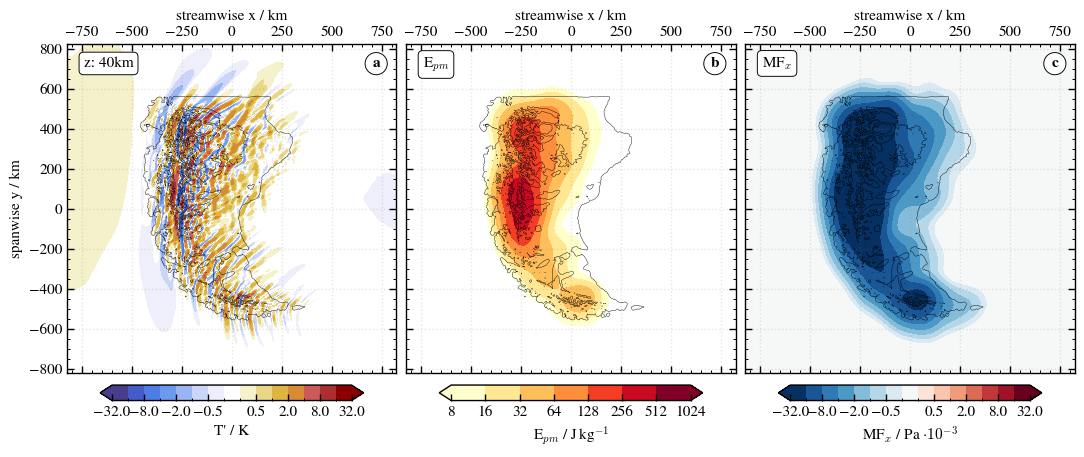

In [28]:
"""Vertical profil of potential energy / Momentum flux"""
# folder = "/work/bd0620/b309199"
folder = "/scratch/b/b309199"
# simulation = "pata_comp_idtopo2"
simulation = "pata_comp_phase0"

fpath = os.path.join(folder, simulation)
ds, ds_env, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars, ds_full = plt_helper.preprocess_eulag_output(fpath)

level = 0
if level == 0:
    dsxy = ds_xyslices[level]
    cbar_mf_label = r"MF$_x$ / Pa $\cdot 10^{-3}$"
else:
    dsxy = ds_xyslices[level]
    cbar_mf_label = r"MF$_x$ / Pa $\cdot 10^{-6}$"
cutoffx = 300*1000

t = 100
xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]

surf_factor = 5
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_ep = plt.get_cmap('YlOrRd')
clev_ep, clev_l_ep = plt_helper.get_colormap_bins_and_labels(max_level=32)
# clev_ep = np.arange(50,500,50)
clev_ep = [8,16,32,64,128,256,512,1024]
norm_ep = BoundaryNorm(boundaries=clev_ep, ncolors=cmap_ep.N, clip=True)

cmap_mf = plt.get_cmap('RdBu_r')
clev_mf, clev_l_mf = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm_mf = BoundaryNorm(boundaries=clev_mf, ncolors=cmap_mf.N, clip=True)

# data = dsxy["th"][t,:,:].values
# lambdax = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=0)
# lambday = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=1)

tloc, tenv = plt_helper.get_eulag_t_and_tenv(dsxy['th'][t,:,:].values, dsxy['the'][t,:,:].values, dsxy['p'][t,:,:].values, dsxy['ppe'][t,:,:].values, ds.cap, ds.pref00)
epm = 1/2*(ds.g/ds.bv)**2 * ((tloc-tenv)/tenv)**2
epm = 1/2*(ds.g/ds.bv)**2 * (dsxy['th'][t,:,:]/dsxy['the'][t,:,:])**2
epv = dsxy['rh0'][t,:,:]*epm
mfx = dsxy['rh0'][t,:,:] * dsxy['w'][t,:,:] * (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:]) 
mfx = plt_helper.gaussian_filter_fft(mfx, cutoffx, cutoffx, ds.dy00, ds.dx00)
epm = plt_helper.gaussian_filter_fft(epm, cutoffx, cutoffx, ds.dy00, ds.dx00)
epm = np.where(epm>clev_ep[0],epm,np.nan)
if level == 0:
    mfx = mfx * 10**3
else:
    mfx = mfx * 10**6
# ep  = subroutines.fft_gaussian_xy(ep,nx_avg,ny_avg=None)
# mfx_obs = 2 * ep * lambdaz/(-lambdax)

"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [8,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(13,5), gridspec_kw=gskw)

ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[0,2]
for ax in axes[-1,0:3]:
    ax.set_axis_off()

ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
contf_th = ax0.contourf(ds.xcr, ds.ycr, tloc-tenv, cmap=cmap, norm=norm, levels=clev, extend='both')
contf_ep = ax1.contourf(ds.xcr, ds.ycr, epm, cmap=cmap_ep, norm=norm_ep, levels=clev_ep, extend='both')
contf_mf = ax2.contourf(ds.xcr, ds.ycr, mfx, cmap=cmap_mf, norm=norm_mf, levels=clev_mf, extend='both')

### - Topography - ###
if ds.itopo == 1:
    amp = dsxy.zcrtopo.max()
    amp = 1200
    topo_levels=np.linspace(20,surf_factor*amp,3)
else:
    if ds.amp < 0:
        topo_levels=np.linspace(surf_factor*ds.amp,-surf_factor*ds.amp,12)
    else: 
        topo_levels=np.linspace(-2*surf_factor*ds.amp,2*surf_factor*ds.amp,24)
ctopo = "k"
lwtopo = 0.3
ax0.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax1.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax2.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)

numstr = ['a','b','c']
for ip, ax in enumerate(axes[0,0:3]):
    ax.text(0.95, 0.93, numstr[ip], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labeltop=True)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('streamwise x / km')
    ax.grid()
    
ax0.text(0.05, 0.93, "z: " + str(int(dsxy.zpos)) + "km", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(0.05, 0.93, "E$_{pm}$", transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.05, 0.93, "MF$_x$", transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
ax0.set_ylabel('spanwise y / km')

cbar = fig.colorbar(contf_th, ax=axes[-1,0], orientation='horizontal', ticks=clev_l, shrink=0.8, fraction=1,aspect=17) # anchor=(0,0)
cbar.set_label(r"T' / K")
cbar = fig.colorbar(contf_ep, ax=axes[-1,1], orientation='horizontal', shrink=0.8, fraction=1, aspect=17)
# cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$ $\cdot 10^{-3}$")
cbar.set_label(r"E$_{pm}$ / J$\,$kg$^{-1}$")
cbar = fig.colorbar(contf_mf, ax=axes[-1,2], orientation='horizontal', ticks=clev_l_mf, shrink=0.8, fraction=1, aspect=17)
cbar.set_label(cbar_mf_label)

fig_title = simulation + "_mf_z" + str(int(dsxy.zpos)) + ".png"
imagefolder = "../data/wavelet"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=120, bbox_inches='tight')

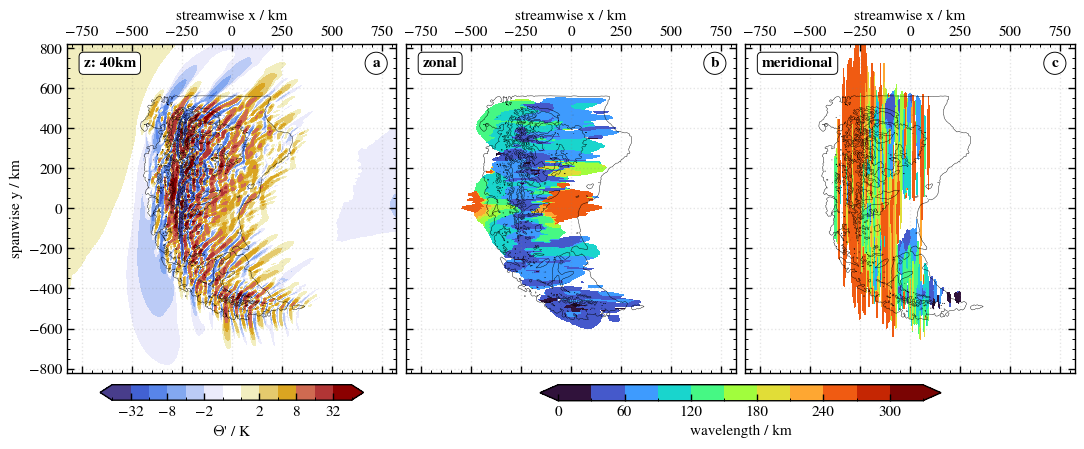

In [99]:
# folder = "/work/bd0620/b309199"
folder = "/scratch/b/b309199"
# simulation = "pata_comp_idtopo2"
simulation = "pata_comp_phase0"
fpath = os.path.join(folder, simulation)
ds, ds_env, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars, ds_full = plt_helper.preprocess_eulag_output(fpath)
dsxy = ds_xyslices[0]
t = 100
data = dsxy["th"][t,:,:].values
xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]

surf_factor = 5
cutoffx = 200*1000
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=64)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_wl = plt.get_cmap('turbo')
clev_wl = np.arange(0,360,30)
norm_wl = BoundaryNorm(boundaries=clev_wl, ncolors=cmap_wl.N, clip=True)

lambdax = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=0)
lambday = plt_helper.wavelet_1D_decomp(data, ds.dx00/1000, dim=1)

ep  = 1/2*dsxy['rh0'][t,:,:]*(ds.g/ds.bv)**2 * (dsxy['th'][t,:,:]/dsxy['the'][t,:,:])**2
mfx = dsxy['rh0'][t,:,:] * dsxy['w'][t,:,:] * (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:]) 
mfx = plt_helper.gaussian_filter_fft(mfx, cutoffx, cutoffx, ds.dy00, ds.dx00)
ep  = plt_helper.gaussian_filter_fft(ep , cutoffx, cutoffx, ds.dy00, ds.dx00)
# ep  = subroutines.fft_gaussian_xy(ep,nx_avg,ny_avg=None)
# mfx_obs = 2 * ep * lambdaz/(-lambdax)

"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [8,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(13,5), gridspec_kw=gskw)

ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[0,2]
for ax in axes[-1,0:3]:
    ax.set_axis_off()

ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
contf_th = ax0.contourf(ds.xcr, ds.ycr, data, cmap=cmap, norm=norm, levels=clev, extend='both')
contf_wl = ax1.contourf(ds.xcr, ds.ycr, lambdax, cmap=cmap_wl, norm=norm_wl, levels=clev_wl, extend='both')
contf_wl = ax2.contourf(ds.xcr, ds.ycr, lambday, cmap=cmap_wl, norm=norm_wl, levels=clev_wl, extend='both')

### - Topography - ###
if ds.itopo == 1:
    amp = dsxy.zcrtopo.max()
    amp = 1200
    topo_levels=np.linspace(20,surf_factor*amp,3)
else:
    if ds.amp < 0:
        topo_levels=np.linspace(surf_factor*ds.amp,-surf_factor*ds.amp,12)
    else: 
        topo_levels=np.linspace(-2*surf_factor*ds.amp,2*surf_factor*ds.amp,24)
ctopo = "k"
lwtopo = 0.3
ax0.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax1.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax2.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)

numstr = ['a','b','c']
for ip, ax in enumerate(axes[0,0:3]):
    ax.text(0.95, 0.93, numstr[ip], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labeltop=True)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('streamwise x / km')
    ax.grid()
    
ax0.text(0.05, 0.93, "z: " + str(int(dsxy.zpos)) + "km", transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(0.05, 0.93, "zonal", transform=ax1.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.05, 0.93, "meridional", transform=ax2.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
ax0.set_ylabel('spanwise y / km')

cbar = fig.colorbar(contf_th, ax=axes[-1,0], orientation='horizontal', ticks=clev_l, shrink=0.8, fraction=1,aspect=17) # anchor=(0,0)
cbar.set_label(r"$\Theta$' / K")
cbar = fig.colorbar(contf_wl, ax=axes[-1,1:3], orientation='horizontal', shrink=0.6, fraction=1, aspect=25)
cbar.set_label('wavelength / km')

fig_title = simulation + "_wavelet_z" + str(int(dsxy.zpos)) + ".png"
imagefolder = "../data/wavelet"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=120, bbox_inches='tight')

In [3]:
def omega(k,l,m):
    f=-1.195e-4 # 55°S
    N=0.02
    H=7000
    omega = ((N**2*(k**2+l**2) + f**2*(m**2+1/(4*H**2)))/(k**2+l**2+m**2+1/(4*H**2)))**(0.5)
    return omega

f=-1.195e-4 # 55°S
ki = 2*np.pi / (750*1000)
li = 2*np.pi / (600*1000)
mi = 2*np.pi / (12*1000)
omega_intrinsic = omega(ki,li,mi)

print('Omega: ', omega_intrinsic)
print('f: ', f)
print('Faktor: ', 1-f**2/omega_intrinsic**2)

Omega:  0.0005212592577387335
f:  -0.0001195
Faktor:  0.9474432806750112
